**Feature Importance** - Feature importance methods assign scores to each feature in a dataset, indicating how much each feature contributes to the model's ability to make accurate predictions. Shap values are one of them.

**Shap (Shapley Additive Explanations) values** - a method for explaining the output of any machine learning model. Game theoretic approach to assign importance values to each feature. Version shap==0.41.0 supports color map changes.


**y** - target numerical variable. ( e.g. Kalorien )


**x**  - numerical data without y


**random. seed(42)** -  a pop-culture reference! In Douglas Adams's popular 1979 science-fiction novel The Hitchhiker's Guide to the Galaxy, towards the end of the book, the supercomputer Deep Thought reveals that the answer to the great question of “life, the universe and everything” is 42.







In [1]:
pip install matplotlib plotly scikit-learn mxnet-mkl==1.6.0 numpy==1.23.1 shap==0.41.0


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 82.4 MB/s eta 0:00:00
  Installing build dependencies ... done
  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Getting requirements to build wheel ... error
error: subprocess-exited-with-error

× Getting requirements to build wheel did not run successfully.
│ exit code: 1
╰─> See above for output.

note: This error originates from a subprocess, and is likely not a problem with pip.


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from IPython import display
import math
pd.set_option('display.max_colwidth', 200)
pd.set_option('display.max_rows', 191)
%matplotlib inline
from pandas import read_excel

import os
import scipy.ndimage
import scipy.stats
import plotly.express as px
from sklearn.feature_selection import SelectKBest,chi2
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import RandomForestRegressor
from sklearn import datasets, ensemble, model_selection

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder
import xgboost as xgb
import seaborn as sns
import numpy as np
np.bool = np.bool_
import shap

In [3]:
print(shap.__version__)

0.50.0


In [4]:
# Load the excel file
my_sheet = 'zucker' # change it to your sheet name, you can find your sheet name at the bottom left of your excel file
file_name = 'Milch2.xlsx' # change it to the name of your excel file
df = read_excel(file_name, sheet_name = my_sheet)
print(df)

                                                    Name  Kalorien Vegan Kalt  \
0                               Mivolis Stevia Tabletten         0     N    N   
1                              Bulk Supplements Aspartam         0     J    N   
2                           Borchers Sucralose Tabletten         0     J    N   
3                              Borchers Sucralose Pulver         0     J    N   
4                          Jeden Tag Tabletten Saccharin         0     N    N   
5          Süsstoff Kandisin Classic Tabletten Saccharin         0     J    N   
6                     Saporepuro Maltitol Pulver, Maltit       210     J    N   
7                               Saporepuro SORBIT Pulver       260     J    N   
8                             Saporepuro Erythrit Pulver         0     J    J   
9                                Saporepuro Xylit Pulver       240     J    J   
10                  Alnatura Bio Rübenzucker, Saccharose       387     J    N   
11                   Sweet F

In [5]:
print (df.dtypes)

Name               object
Kalorien            int64
Vegan              object
Kalt               object
Glutenfrei         object
Süsskraft         float64
GI                float64
Herkunft           object
Typ                object
Kohlenhydraten    float64
Stabil             object
Nachteile          object
Info               object
dtype: object


In [6]:
df.index.values

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28])

In [7]:
df.columns = df.columns.str.strip()

In [8]:
df.set_index("Name",drop=True,inplace=True)

In [9]:
# Declare Categorical and Numerical Columns

In [10]:
# Data
X = df.drop(['Kalorien'], axis=1)
#print(df_num)

# Target
y = df['Kalorien']
#print(y)

In [11]:
# Data
categorical_columns = ["Herkunft","Kalt", "Vegan", "Glutenfrei","Typ", "Stabil","Nachteile","Info"]
numerical_columns = ["Süsskraft","GI", "Kohlenhydraten"]

In [12]:
# fit model
enc = OrdinalEncoder()
X[categorical_columns] = enc.fit_transform(X[categorical_columns] )
# Combine Numerical and categorical data
x = X[categorical_columns + numerical_columns]


In [13]:
# Default test_size is 0.25, or 25 percent.
# 25 percent of samples are assigned to the test set, 75% is for training
#x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2, random_state=42)
x_train, x_test, y_train, y_test = train_test_split(x,y, random_state=0)

In [14]:
# Create and train the RandomForestRegressor
regressor = ensemble.RandomForestRegressor()
regressor.fit(x_train, y_train)

RandomForestRegressor()

In [15]:
# Create an explainer for the RandomForestRegressor
explainer = shap.TreeExplainer(regressor)

# Calculate SHAP values for the training dataset
shap_values = explainer.shap_values(x_train)

In [16]:
# Assuming 'shap_values' and 'X_train' are already calculated
features = x_train.columns.tolist()

In [17]:
# sort by Kalorien descending
df = df.sort_values('Kalorien', ascending=False)

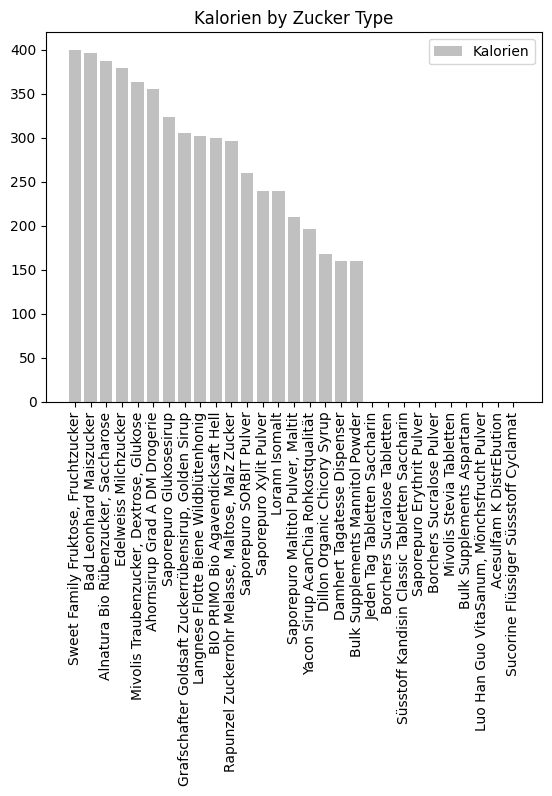

In [18]:
# generate the basic plot
fig, ax = plt.subplots()
ax.bar(df.index, df['Kalorien'], label='Kalorien',color='#C0C0C0')
ax.set_title('Kalorien by Zucker Type')
ax.tick_params(axis='x', labelrotation=90)
ax.legend()

In [19]:
# sort by GI descending
df = df.sort_values('GI', ascending=False)

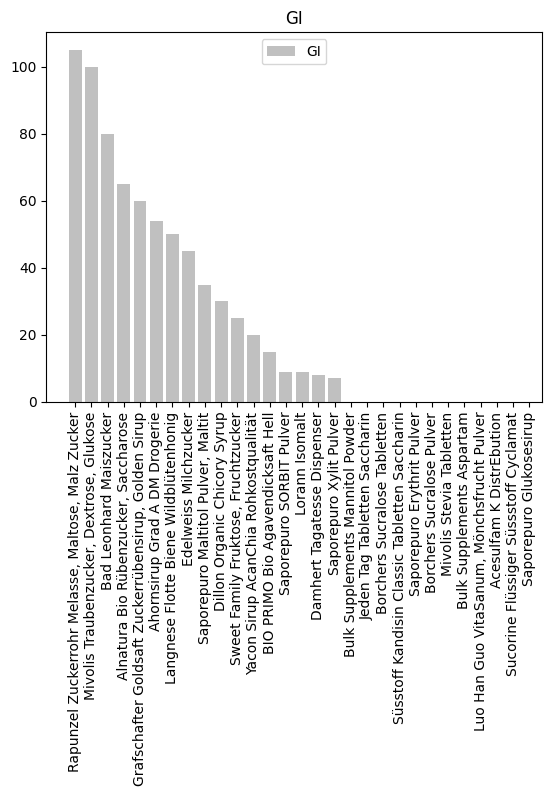

In [20]:
# generate the basic plot
fig, ax = plt.subplots()
ax.bar(df.index, df['GI'], label='GI',color='#C0C0C0')
ax.set_title('GI')
ax.tick_params(axis='x', labelrotation=90)
ax.legend()

In [21]:
# sort by Süsskraft descending
df = df.sort_values('Süsskraft', ascending=False)

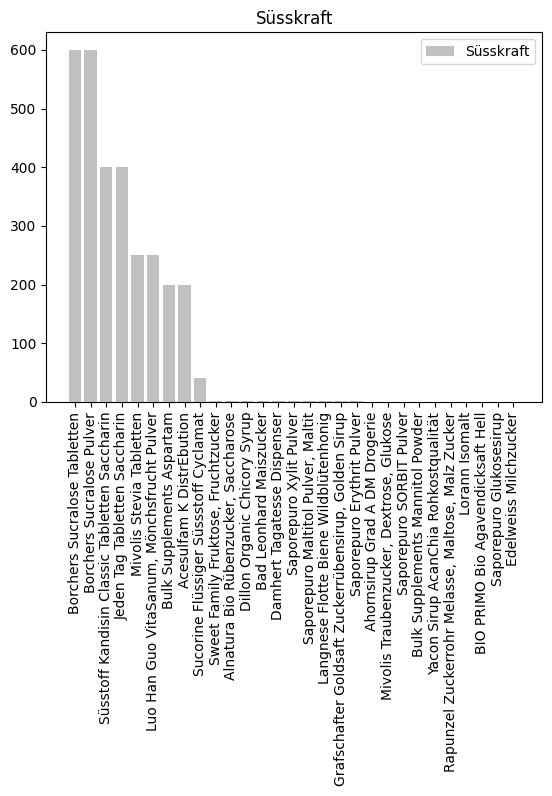

In [22]:
# generate the basic plot
fig, ax = plt.subplots()
ax.bar(df.index, df['Süsskraft'], label='Süsskraft',color='#C0C0C0')
ax.set_title('Süsskraft')
ax.tick_params(axis='x', labelrotation=90)
ax.legend()

In [23]:
# sort by Kohlenhydraten descending
df = df.sort_values('Kohlenhydraten', ascending=False)

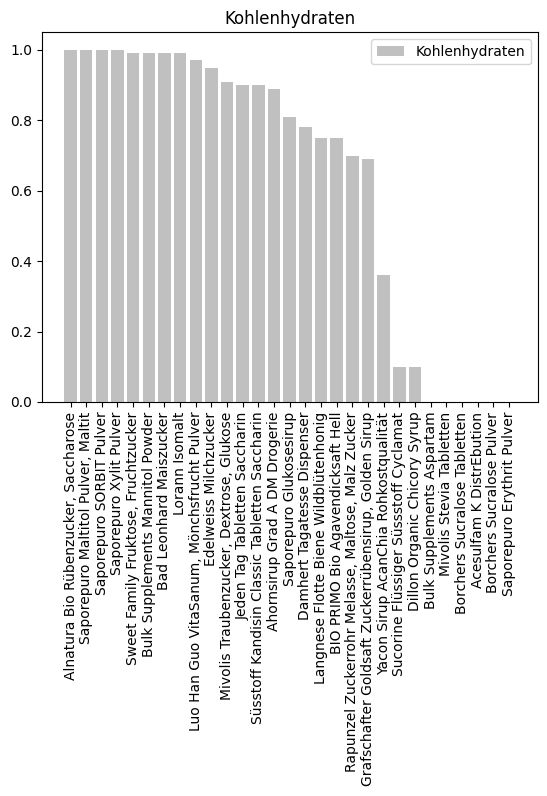

In [24]:
# generate the basic plot
fig, ax = plt.subplots()
ax.bar(df.index, df['Kohlenhydraten'], label='Kohlenhydraten',color='#C0C0C0')
ax.set_title('Kohlenhydraten')
ax.tick_params(axis='x', labelrotation=90)
ax.legend()

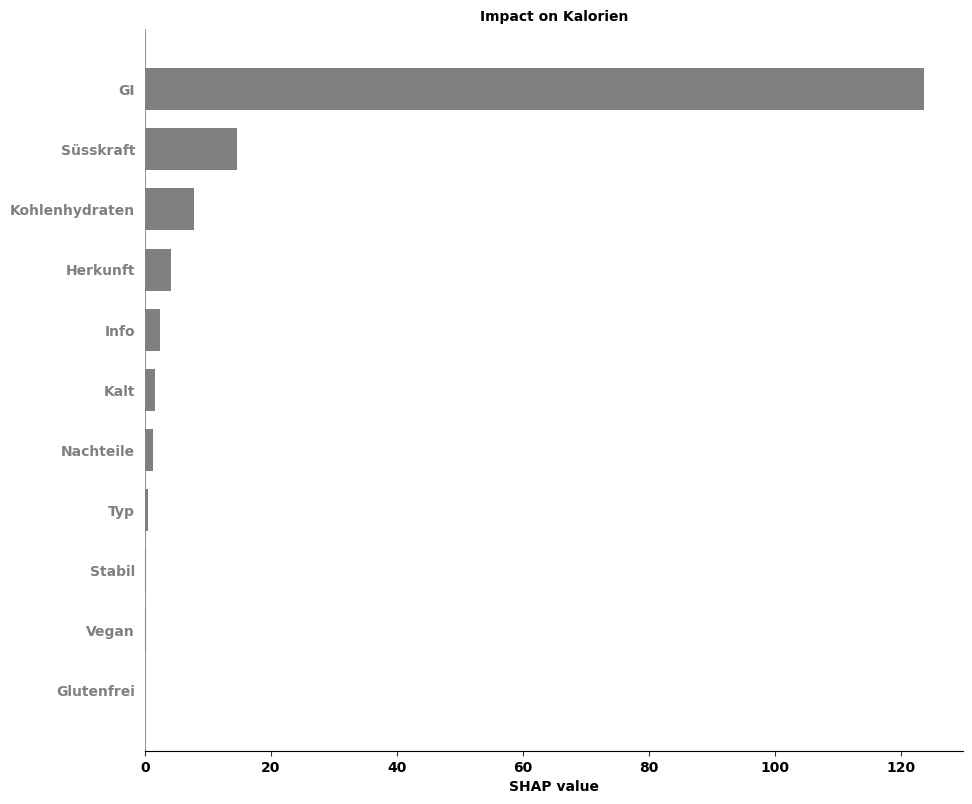

In [25]:
shap.summary_plot(shap_values, x_train,show=False, feature_names=features, plot_size=(10,8), plot_type="bar", color="grey")
plt.title('Impact on Kalorien',fontsize=15,fontproperties="DejaVu Sans",weight='bold')
plt.yticks(fontsize=10,color='grey',fontproperties="DejaVu Sans",weight='bold')
plt.xticks(fontsize=10,color='black',fontproperties="DejaVu Sans",weight='bold')
plt.xlabel('SHAP value',fontsize=10,fontproperties="DejaVu Sans",weight='bold')
plt.show()

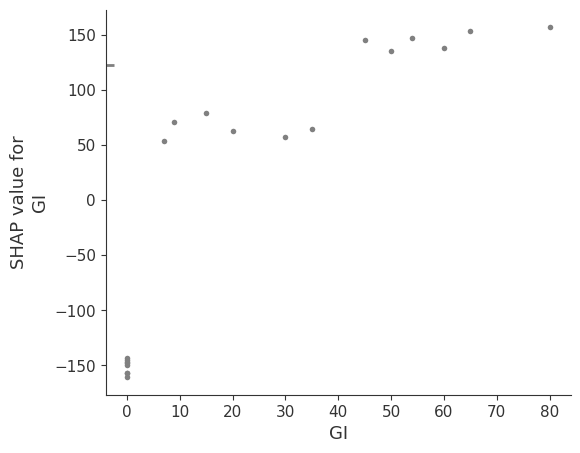

In [42]:
# Assuming 'shap_values', 'X_train', and 'features' are available
# create only primary axis: set interaction_index=None
shap.dependence_plot("GI", shap_values, x_train, interaction_index=None, color="Grey")
plt.show()
#plt.show()

In [34]:
# x_train and y_train rows count (e.g. 15) must be the same
print(x_train.shape)
print(y_train.shape)

(21, 11)
(21,)


In [ ]:
# print(x_train)

In [ ]:
# print(y_train)